# Assignment 6: Clustering Techniques Implementation and Performance Evaluation

## Problem Statement
Implement clustering techniques and evaluate their performance on a real dataset.

## Objectives
1. Implement **K-Means**, **K-Medoids**, and **DBSCAN**.
2. Perform a comparative performance evaluation of these methods.

## Theory (Short Notes)
1. **K-Means**: Partitions data into $k$ clusters by minimizing within-cluster squared distances to centroids.
2. **K-Medoids**: Similar to K-Means, but cluster centers are actual data points (medoids), making it more robust to outliers.
3. **Spectral Clustering**: Uses graph-based similarity and eigenvectors of a Laplacian matrix to find non-convex structures.
4. **DBSCAN**: Density-based clustering that groups dense regions and marks sparse points as noise.
5. **Hierarchical Clustering**: Builds a nested tree of clusters (agglomerative/divisive), useful for multi-level grouping exploration.

## Operations Performed (Workflow)
1. Import Python libraries.
2. Load and inspect dataset.
3. Perform statistical and outlier analysis.
4. Create independent and dependent variables.
5. Replace missing/invalid values with meaningful values.
6. Split into train/test and scale features.
7. Apply clustering and evaluate.
8. Compare methods using multiple metrics.

In [1]:
# 1. Importing Python Modules/Libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
 )
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="notebook")

In [10]:
# 2. Importing data & Displaying data
df = pd.read_csv("datasets/iris.csv")

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing values (raw dataset):")
print(df.isnull().sum())

print("\nClass distribution (variety):")
print(df["variety"].value_counts())

Dataset shape: (150, 5)

First 5 rows:


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values (raw dataset):
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

Class distribution (variety):
variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


Statistical Summary:


,sepal.length,sepal.width,petal.length,petal.width,variety
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


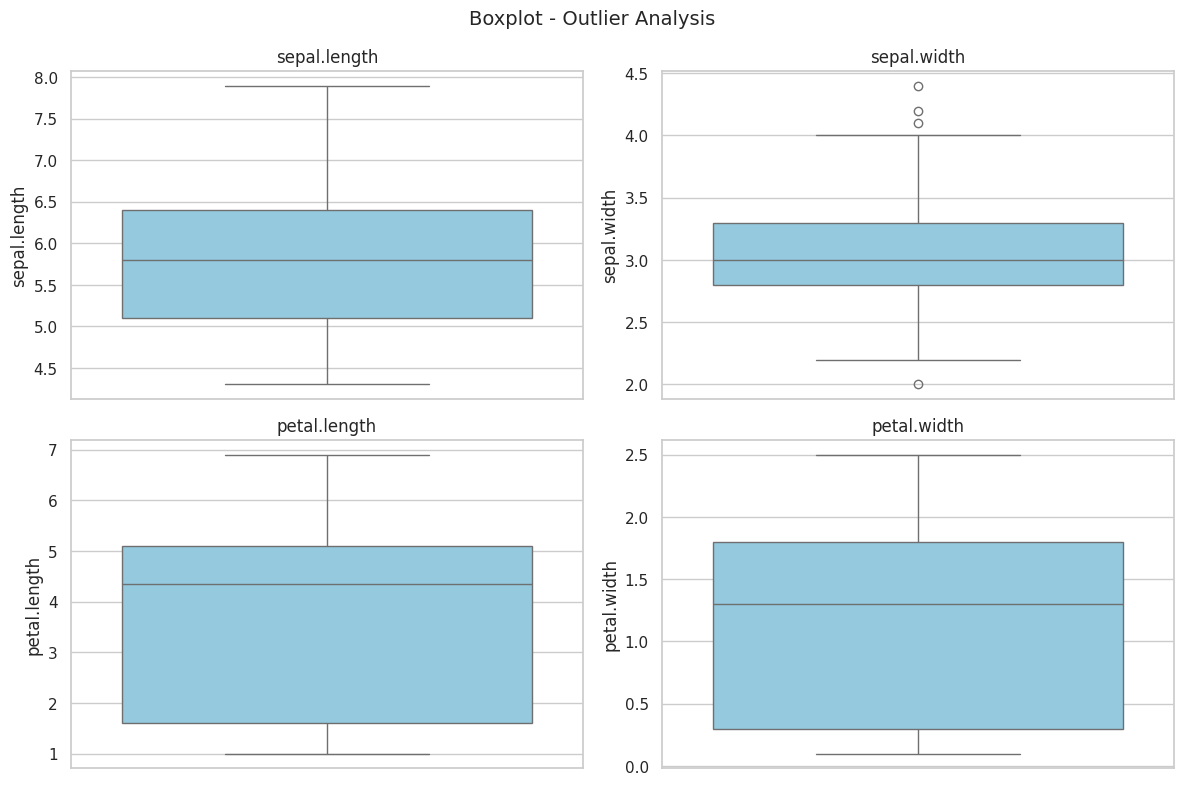


Outlier count (IQR method):
  sepal.length: 0 outliers
  sepal.width: 4 outliers
  petal.length: 0 outliers
  petal.width: 0 outliers


In [11]:
# 3. Statistical analysis & Outlier analysis
print("Statistical Summary:")
display(df.describe(include="all"))

numeric_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

plt.suptitle("Boxplot - Outlier Analysis", fontsize=14)
plt.tight_layout()
plt.show()

print("\nOutlier count (IQR method):")
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {outliers} outliers")

In [12]:
# 4. Creating the Independent and Dependent variables
X = df.drop("variety", axis=1).copy()
y = df["variety"].copy()

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nTarget distribution:")
print(y.value_counts())

Features (X) shape: (150, 4)
Target (y) shape: (150,)

Target distribution:
variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [13]:
# 5. Replacing missing values with meaningful value
# Iris is mostly clean; if any missing numeric values exist, impute with median
missing_before = X.isnull().sum()
print("Missing values before imputation:")
print(missing_before)

num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

print("\nMissing values after imputation:")
print(X.isnull().sum())

Missing values before imputation:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
dtype: int64

Missing values after imputation:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
dtype: int64


In [14]:
# 6. Splitting the data into training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For unsupervised clustering comparison, use train+test transformed with train scaler
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
y_all = np.concatenate([y_train.values, y_test.values])

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Combined scaled matrix shape: {X_all_scaled.shape}")

Training set size: 120
Test set size: 30
Combined scaled matrix shape: (150, 4)


Best k for K-Means based on train silhouette: 2


,Model,n_clusters,noise_points,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,homogeneity,completeness,v_measure,Mapped_Accuracy,Mapped_Precision,Mapped_Recall,Mapped_F1
0,K-Means,2,0,0.584415,256.165247,0.587130,0.568116,0.733680,0.579380,1.000000,0.733680,0.666667,0.500000,0.666667,0.555556
1,K-Medoids,2,0,0.584415,256.165247,0.587130,0.568116,0.733680,0.579380,1.000000,0.733680,0.666667,0.500000,0.666667,0.555556
2,DBSCAN,2,4,0.600327,282.296152,0.563337,0.551755,0.689979,0.578631,0.854393,0.689979,0.678082,0.505155,0.666667,0.560091



DBSCAN parameter used:
  min_samples = 5
  eps (90th percentile of k-distance) = 0.8322


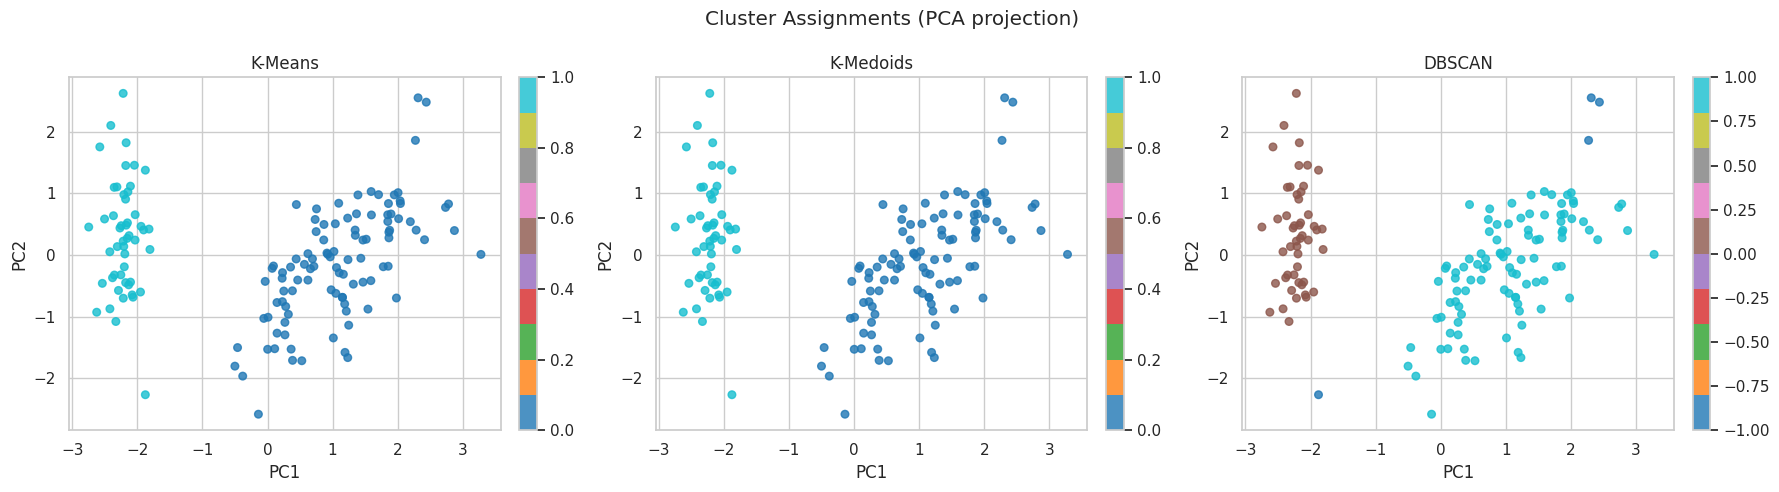

In [15]:
# 7. Apply clustering techniques and check their performance

def evaluate_clustering(X_data, y_true, labels, model_name):
    results = {"Model": model_name}

    unique_labels = set(labels)
    clusters_wo_noise = sorted([c for c in unique_labels if c != -1])
    n_clusters = len(clusters_wo_noise)
    noise_points = int(np.sum(labels == -1))

    results["n_clusters"] = n_clusters
    results["noise_points"] = noise_points

    # Internal metrics (computed only when valid)
    if n_clusters >= 2:
        if noise_points > 0:
            mask = labels != -1
            if len(set(labels[mask])) >= 2 and np.sum(mask) > len(set(labels[mask])):
                results["silhouette"] = silhouette_score(X_data[mask], labels[mask])
                results["calinski_harabasz"] = calinski_harabasz_score(X_data[mask], labels[mask])
                results["davies_bouldin"] = davies_bouldin_score(X_data[mask], labels[mask])
            else:
                results["silhouette"] = np.nan
                results["calinski_harabasz"] = np.nan
                results["davies_bouldin"] = np.nan
        else:
            results["silhouette"] = silhouette_score(X_data, labels)
            results["calinski_harabasz"] = calinski_harabasz_score(X_data, labels)
            results["davies_bouldin"] = davies_bouldin_score(X_data, labels)
    else:
        results["silhouette"] = np.nan
        results["calinski_harabasz"] = np.nan
        results["davies_bouldin"] = np.nan

    # External metrics using true labels
    results["ARI"] = adjusted_rand_score(y_true, labels)
    results["NMI"] = normalized_mutual_info_score(y_true, labels)
    results["homogeneity"] = homogeneity_score(y_true, labels)
    results["completeness"] = completeness_score(y_true, labels)
    results["v_measure"] = v_measure_score(y_true, labels)

    return results


def cluster_to_class_metrics(y_true, labels):
    # Map each cluster to majority true class and compute supervised-style metrics
    valid_mask = labels != -1
    if valid_mask.sum() == 0:
        return np.nan, np.nan, np.nan, np.nan

    y_true_valid = y_true[valid_mask]
    labels_valid = labels[valid_mask]

    cluster_to_class = {}
    for cluster_id in np.unique(labels_valid):
        class_mode = pd.Series(y_true_valid[labels_valid == cluster_id]).mode().iloc[0]
        cluster_to_class[cluster_id] = class_mode

    y_pred_from_clusters = np.array([cluster_to_class[c] for c in labels_valid])

    acc = accuracy_score(y_true_valid, y_pred_from_clusters)
    precision = precision_score(y_true_valid, y_pred_from_clusters, average="macro", zero_division=0)
    recall = recall_score(y_true_valid, y_pred_from_clusters, average="macro", zero_division=0)
    f1 = f1_score(y_true_valid, y_pred_from_clusters, average="macro", zero_division=0)

    return acc, precision, recall, f1


def kmedoids_pam(X_data, k=2, max_iter=100, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = X_data.shape[0]

    # Precompute pairwise distance matrix for efficiency
    distance_matrix = np.sqrt(((X_data[:, None, :] - X_data[None, :, :]) ** 2).sum(axis=2))

    medoid_indices = rng.choice(n_samples, size=k, replace=False)

    for _ in range(max_iter):
        # Assignment step
        distances_to_medoids = distance_matrix[:, medoid_indices]
        labels = np.argmin(distances_to_medoids, axis=1)

        new_medoid_indices = medoid_indices.copy()
        # Update step
        for cluster_idx in range(k):
            cluster_points = np.where(labels == cluster_idx)[0]
            if len(cluster_points) == 0:
                continue
            intra_distances = distance_matrix[np.ix_(cluster_points, cluster_points)]
            total_distances = intra_distances.sum(axis=1)
            best_point = cluster_points[np.argmin(total_distances)]
            new_medoid_indices[cluster_idx] = best_point

        if np.array_equal(new_medoid_indices, medoid_indices):
            break
        medoid_indices = new_medoid_indices

    final_distances = distance_matrix[:, medoid_indices]
    final_labels = np.argmin(final_distances, axis=1)
    return final_labels, medoid_indices


results = []
labels_dict = {}

# ---- K-Means ----
k_values = range(2, 8)
k_sil_scores = []
for k in k_values:
    km_temp = KMeans(n_clusters=k, n_init=20, random_state=42)
    lbl_temp = km_temp.fit_predict(X_train_scaled)
    k_sil_scores.append(silhouette_score(X_train_scaled, lbl_temp))

best_k = list(k_values)[int(np.argmax(k_sil_scores))]
print(f"Best k for K-Means based on train silhouette: {best_k}")

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=42)
labels_kmeans = kmeans.fit_predict(X_all_scaled)
labels_dict["K-Means"] = labels_kmeans

res_kmeans = evaluate_clustering(X_all_scaled, y_all, labels_kmeans, "K-Means")
acc, pre, rec, f1 = cluster_to_class_metrics(y_all, labels_kmeans)
res_kmeans.update({"Mapped_Accuracy": acc, "Mapped_Precision": pre, "Mapped_Recall": rec, "Mapped_F1": f1})
results.append(res_kmeans)

# ---- K-Medoids (PAM) ----
labels_kmedoids, medoids = kmedoids_pam(X_all_scaled, k=best_k, max_iter=100, random_state=42)
labels_dict["K-Medoids"] = labels_kmedoids

res_kmedoids = evaluate_clustering(X_all_scaled, y_all, labels_kmedoids, "K-Medoids")
acc, pre, rec, f1 = cluster_to_class_metrics(y_all, labels_kmedoids)
res_kmedoids.update({"Mapped_Accuracy": acc, "Mapped_Precision": pre, "Mapped_Recall": rec, "Mapped_F1": f1})
results.append(res_kmedoids)

# ---- DBSCAN ----
# Estimate epsilon using distance to kth nearest neighbor
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_train_scaled)
distances, _ = nn.kneighbors(X_train_scaled)
k_dist = np.sort(distances[:, -1])
eps_estimate = float(np.percentile(k_dist, 90))

dbscan = DBSCAN(eps=eps_estimate, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_all_scaled)
labels_dict["DBSCAN"] = labels_dbscan

res_dbscan = evaluate_clustering(X_all_scaled, y_all, labels_dbscan, "DBSCAN")
acc, pre, rec, f1 = cluster_to_class_metrics(y_all, labels_dbscan)
res_dbscan.update({"Mapped_Accuracy": acc, "Mapped_Precision": pre, "Mapped_Recall": rec, "Mapped_F1": f1})
results.append(res_dbscan)

results_df = pd.DataFrame(results)
display(results_df)

print("\nDBSCAN parameter used:")
print(f"  min_samples = {min_samples}")
print(f"  eps (90th percentile of k-distance) = {eps_estimate:.4f}")

# PCA 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, labels_model) in zip(axes, labels_dict.items()):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_model, cmap="tab10", s=30, alpha=0.8)
    ax.set_title(model_name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Cluster Assignments (PCA projection)")
plt.tight_layout()
plt.show()

Clustering Performance Comparison:


,Model,n_clusters,noise_points,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,homogeneity,completeness,v_measure,Mapped_Accuracy,Mapped_Precision,Mapped_Recall,Mapped_F1
2,DBSCAN,2,4,0.6003,282.2962,0.5633,0.5518,0.6900,0.5786,0.8544,0.6900,0.6781,0.5052,0.6667,0.5601
0,K-Means,2,0,0.5844,256.1652,0.5871,0.5681,0.7337,0.5794,1.0000,0.7337,0.6667,0.5000,0.6667,0.5556
1,K-Medoids,2,0,0.5844,256.1652,0.5871,0.5681,0.7337,0.5794,1.0000,0.7337,0.6667,0.5000,0.6667,0.5556


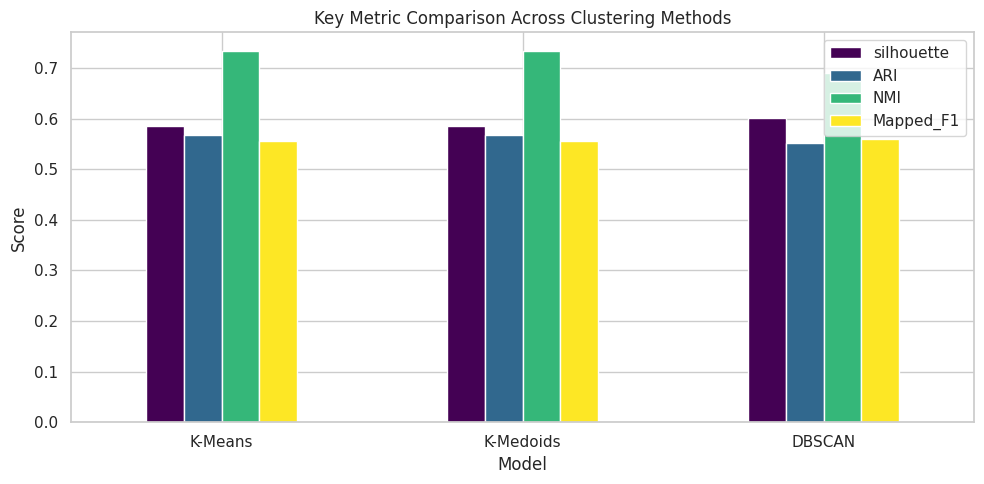

Best method by internal metric (Silhouette):
  DBSCAN (silhouette = 0.6003)

Best method by external metric (ARI with Outcome labels):
  K-Means (ARI = 0.5681)

Conclusion:
- K-Means and K-Medoids are centroid/medoid-based partitioning methods and are sensitive to chosen k.
- DBSCAN can detect noise and non-spherical groups but depends strongly on eps and min_samples.
- For this dataset, use both internal and external metrics before deciding the best clustering model.


In [16]:
# 8. Compare the performance of various clustering methods
# Better for silhouette/CH: higher; better for Davies-Bouldin: lower
comparison_cols = [
    "Model", "n_clusters", "noise_points",
    "silhouette", "calinski_harabasz", "davies_bouldin",
    "ARI", "NMI", "homogeneity", "completeness", "v_measure",
    "Mapped_Accuracy", "Mapped_Precision", "Mapped_Recall", "Mapped_F1",
]

comparison = results_df[comparison_cols].copy()
comparison_sorted = comparison.sort_values(by=["silhouette", "ARI"], ascending=[False, False])

print("Clustering Performance Comparison:")
display(comparison_sorted.round(4))

# Bar chart for key metrics
plot_df = comparison.set_index("Model")[["silhouette", "ARI", "NMI", "Mapped_F1"]]
plot_df.plot(kind="bar", figsize=(10, 5), rot=0, colormap="viridis")
plt.title("Key Metric Comparison Across Clustering Methods")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

best_internal = comparison.dropna(subset=["silhouette"]).sort_values("silhouette", ascending=False).iloc[0]
best_external = comparison.sort_values("ARI", ascending=False).iloc[0]

print("Best method by internal metric (Silhouette):")
print(f"  {best_internal['Model']} (silhouette = {best_internal['silhouette']:.4f})")

print("\nBest method by external metric (ARI with Outcome labels):")
print(f"  {best_external['Model']} (ARI = {best_external['ARI']:.4f})")

print("\nConclusion:")
print("- K-Means and K-Medoids are centroid/medoid-based partitioning methods and are sensitive to chosen k.")
print("- DBSCAN can detect noise and non-spherical groups but depends strongly on eps and min_samples.")
print("- For this dataset, use both internal and external metrics before deciding the best clustering model.")

## FAQs

### 1) What is K-means clustering and how does it work?
K-means partitions data into $k$ clusters by iteratively assigning points to the nearest centroid and updating centroids as cluster means until convergence.

### 2) What is DBSCAN clustering and how does it work?
DBSCAN groups points that are density-connected using two parameters: `eps` (neighborhood radius) and `min_samples` (minimum points to form a dense region). Points not belonging to dense regions are labeled as noise.

### 3) How do you choose the optimal number of clusters in K-means clustering?
Common methods include the **Elbow method**, **Silhouette score**, and **domain knowledge**. In this notebook, silhouette score is used to select the best $k$ from a candidate range.

### 4) Can DBSCAN clustering handle datasets with different densities?
Not perfectly with a single global `eps`. DBSCAN can struggle when densities vary significantly. Variants like **HDBSCAN** are often preferred in such cases.

### 5) Difference between spectral clustering and hierarchical clustering
- **Spectral clustering** uses graph connectivity (eigen-decomposition) and works well for complex/non-convex shapes.
- **Hierarchical clustering** builds a dendrogram showing nested clusters and does not require fixing $k$ upfront (you can cut the tree at different levels).